# ImageCLEFmed GANs 2026 — Task 3: CT Generation
### v4 — Lean model, heavy R1, 300 epochs + early stopping

## 1 — Setup

In [ ]:
import os, sys, json, time, math, copy, shutil, zipfile, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import save_image, make_grid
from torchvision.transforms.functional import pil_to_tensor, resize
warnings.filterwarnings('ignore')
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
%matplotlib inline

if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'PyTorch {torch.__version__} | {device}')

PyTorch 2.11.0 | mps


## 2 — Config

In [ ]:
DATA_ROOT  = os.path.expanduser('~/Desktop/GAN3')
DEV_DIR    = os.path.join(DATA_ROOT, 'ImageCLEF_GANs2026_Privacy-preserving_CT_generation_DEV')
VAL_DIR    = os.path.join(DATA_ROOT, 'Validation')
OUTPUT_DIR = os.path.join(DATA_ROOT, 'output_v4')

C = {
    'z_dim': 128,           # small latent
    'g_ch': 48,             # lean G — enough for greyscale CT
    'd_ch': 24,             # lean D — intentionally weak
    'epochs': 300,
    'batch_size': 64,       # large batches = faster epochs
    'lr_g': 1e-4,
    'lr_d': 1e-5,           # 10× slower than G
    'r1_weight': 100.0,     # VERY strong R1 — prevents D from dominating
    'r1_every': 8,          # compute R1 frequently
    'ema_decay': 0.999,
    'use_dp': False,
    'dp_clip': 1.0,
    'dp_noise': 0.5,
}

for d in [OUTPUT_DIR, f'{OUTPUT_DIR}/samples', f'{OUTPUT_DIR}/checkpoints']:
    os.makedirs(d, exist_ok=True)

dev_n = len([f for f in os.listdir(DEV_DIR) if f.endswith('.png')]) if os.path.exists(DEV_DIR) else 0
val_n = len([f for f in os.listdir(VAL_DIR) if f.endswith('.png')]) if os.path.exists(VAL_DIR) else 0
print(f'Dev: {dev_n} | Val: {val_n} | Total: {dev_n+val_n}')
print(f'Batches/epoch: ~{(dev_n+val_n)//C["batch_size"]}')
print(f'Output: {OUTPUT_DIR}')

Dev: 10000 | Val: 1003 | Total: 11003
Batches/epoch: ~171
Output: /Users/cherubim/Desktop/GAN3/output_v4


## 3 — Model (lean DCGAN-style)

In [ ]:
def upblock(ic, oc):
    """Generator: upsample 2× + conv + batchnorm-free."""
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(ic, oc, 3, 1, 1, bias=False),
        nn.GroupNorm(min(8, oc), oc),  # GroupNorm: stable, no batch dependency
        nn.LeakyReLU(0.2, True),
        nn.Conv2d(oc, oc, 3, 1, 1, bias=False),
        nn.GroupNorm(min(8, oc), oc),
        nn.LeakyReLU(0.2, True),
    )

def downblock(ic, oc):
    """Discriminator: conv + downsample 2×."""
    return nn.Sequential(
        nn.Conv2d(ic, oc, 3, 1, 1),
        nn.LeakyReLU(0.2, True),
        nn.Conv2d(oc, oc, 3, 1, 1),
        nn.LeakyReLU(0.2, True),
        nn.AvgPool2d(2),
    )

class Generator(nn.Module):
    def __init__(self, z=128, ch=48):
        super().__init__()
        self.z_dim = z
        self.ch = ch
        c = ch
        # z → 4×4 with 8*ch channels
        self.fc = nn.Linear(z, 8*c * 4 * 4)
        self.blocks = nn.ModuleList([
            upblock(8*c, 8*c),  # 4→8
            upblock(8*c, 4*c),  # 8→16
            upblock(4*c, 2*c),  # 16→32
            upblock(2*c, c),    # 32→64
            upblock(c, c),      # 64→128
            upblock(c, c),      # 128→256
        ])
        self.to_img = nn.Sequential(
            nn.Conv2d(c, 1, 3, 1, 1),
            nn.Tanh(),
        )
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(m.weight, a=0.2)
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, z):
        x = self.fc(z).view(-1, 8*self.ch, 4, 4)
        for b in self.blocks:
            x = b(x)
        return self.to_img(x)


class Discriminator(nn.Module):
    def __init__(self, ch=24):
        super().__init__()
        c = ch
        self.net = nn.Sequential(
            # 256→128
            nn.Conv2d(1, c, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.AvgPool2d(2),
            # 128→64→32→16→8→4
            *[layer for ic, oc in [
                (c, 2*c), (2*c, 4*c), (4*c, 4*c),
                (4*c, 4*c), (4*c, 4*c)
            ] for layer in [
                nn.Conv2d(ic, oc, 3, 1, 1), nn.LeakyReLU(0.2, True),
                nn.Conv2d(oc, oc, 3, 1, 1), nn.LeakyReLU(0.2, True),
                nn.AvgPool2d(2),
            ]],
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4*c * 4 * 4, 1),
        )
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(m.weight, a=0.2)
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.net(x))


def r1_penalty(d_out, real):
    g = torch.autograd.grad(d_out.sum(), real, create_graph=True, retain_graph=True)[0]
    return g.pow(2).view(g.size(0), -1).sum(1).mean()


G = Generator(z=C['z_dim'], ch=C['g_ch']).to(device)
D = Discriminator(ch=C['d_ch']).to(device)
gp = sum(p.numel() for p in G.parameters())
dp = sum(p.numel() for p in D.parameters())
print(f'G: {gp:,} | D: {dp:,} | Total: {gp+dp:,}')

# Verify shapes
with torch.no_grad():
    test_out = G(torch.randn(2, C['z_dim'], device=device))
    test_s = D(test_out)
print(f'G→{test_out.shape} D→{test_s.shape} ✓')
del test_out, test_s
if device.type == 'mps': torch.mps.empty_cache()

G: 4,839,793 | D: 655,825 | Total: 5,495,618
G→torch.Size([2, 1, 256, 256]) D→torch.Size([2, 1]) ✓


## 4 — Data

Loading 11003 images... 8.5s
11003 images, 171 batches/epoch


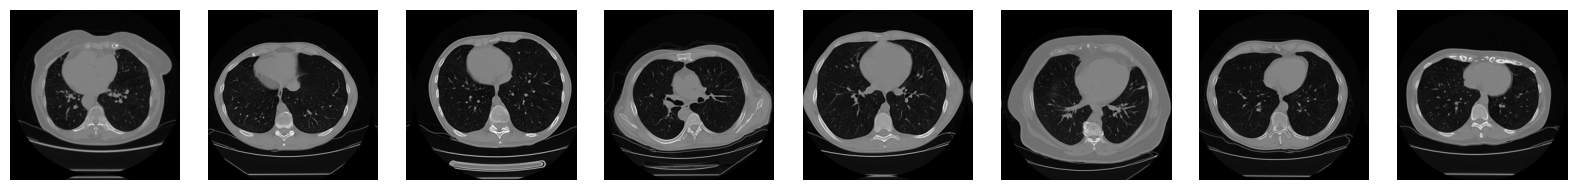

In [ ]:
class CTData(Dataset):
    def __init__(self, dirs):
        if isinstance(dirs, str): dirs = [dirs]
        files = []
        for d in dirs:
            if os.path.exists(d):
                files += sorted([f for f in Path(d).iterdir() if f.suffix.lower() == '.png'])
        assert files, f'No images in {dirs}'
        print(f'Loading {len(files)} images...', end=' ')
        t0 = time.time()
        self.data = torch.empty(len(files), 1, 256, 256, dtype=torch.uint8)
        for i, f in enumerate(files):
            t = pil_to_tensor(Image.open(f).convert('L'))
            if t.shape[1] != 256 or t.shape[2] != 256:
                t = resize(t, [256, 256], antialias=True)
            self.data[i] = t
        print(f'{time.time()-t0:.1f}s')

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        img = self.data[i].float() / 127.5 - 1.0
        if torch.rand(1) < 0.5: img = torch.flip(img, [-1])
        p = 13
        img = F.pad(img.unsqueeze(0), [p]*4, mode='reflect').squeeze(0)
        y, x = torch.randint(0, 2*p, (2,)).tolist()
        return img[:, y:y+256, x:x+256]

ds = CTData([DEV_DIR, VAL_DIR])
dl = DataLoader(ds, batch_size=C['batch_size'], shuffle=True, num_workers=0, drop_last=True)
print(f'{len(ds)} images, {len(dl)} batches/epoch')

fig, ax = plt.subplots(1, 8, figsize=(16, 2))
b = next(iter(dl))
for i in range(8): ax[i].imshow(b[i,0].numpy(), cmap='gray', vmin=-1, vmax=1); ax[i].axis('off')
plt.tight_layout(); plt.show()

## 5 — Train (300 max + early stop)

Resumed epoch 10

═════════════════════════════════════════════════════════════════
  Max 300 epochs | early stop: patience=30, min=80
  lr_G=0.0001 lr_D=1e-05 (ratio 10:1)
  R1 γ=100.0 every 8 steps
  batch=64 | 171 batches/epoch
═════════════════════════════════════════════════════════════════

E  10/300 │ D 1.3788 │ G 0.7010 │ R1 0.0002 │ 226s │ ETA 1088m │ [min epoch 80]
E  15/300 │ D 1.3859 │ G 0.6959 │ R1 0.0001 │ 212s │ ETA 1024m │ [min epoch 80]
E  20/300 │ D 1.3861 │ G 0.6955 │ R1 0.0001 │ 213s │ ETA 998m │ [min epoch 80]
E  25/300 │ D 1.3873 │ G 0.6952 │ R1 0.0001 │ 215s │ ETA 979m │ [min epoch 80]
  ✓ saved
E  30/300 │ D 1.3869 │ G 0.6931 │ R1 0.0001 │ 373s │ ETA 2294m │ [min epoch 80]
E  35/300 │ D 1.3842 │ G 0.6958 │ R1 0.0001 │ 579s │ ETA 2291m │ [min epoch 80]
E  40/300 │ D 1.3881 │ G 0.6935 │ R1 0.0000 │ 452s │ ETA 2986m │ [min epoch 80]
E  45/300 │ D 1.3871 │ G 0.6937 │ R1 0.0000 │ 2946s │ ETA 3126m │ [min epoch 80]
E  50/300 │ D 1.3878 │ G 0.6933 │ R1 0.0000 │ 574s │ 

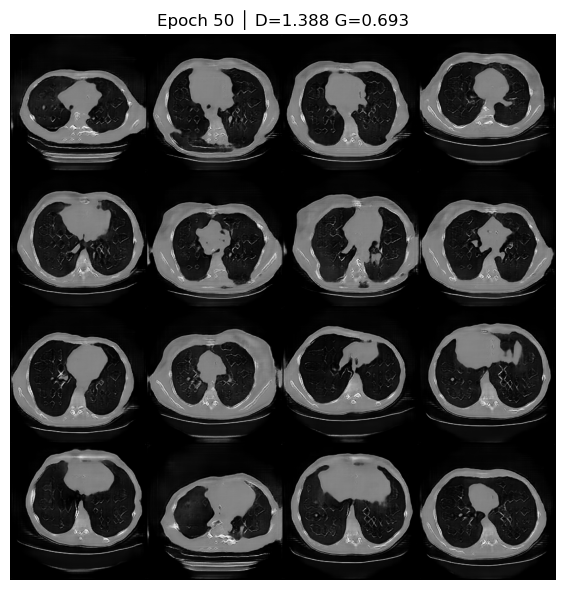

  ✓ saved
E  55/300 │ D 1.3871 │ G 0.6937 │ R1 0.0000 │ 579s │ ETA 2827m │ [min epoch 80]
E  60/300 │ D 1.3868 │ G 0.6935 │ R1 0.0000 │ 1799s │ ETA 3047m │ [min epoch 80]
E  65/300 │ D 1.3870 │ G 0.6935 │ R1 0.0000 │ 211s │ ETA 2791m │ [min epoch 80]
E  70/300 │ D 1.3863 │ G 0.6939 │ R1 0.0000 │ 211s │ ETA 2574m │ [min epoch 80]
E  75/300 │ D 1.3868 │ G 0.6932 │ R1 0.0000 │ 211s │ ETA 2387m │ [min epoch 80]
  ✓ saved
E  80/300 │ D 1.3867 │ G 0.6924 │ R1 0.0000 │ 212s │ ETA 2241m │ [patience 61/30]

🛑 Early stopping at epoch 80 (no improvement for 30 epochs)
   Best smoothed G loss: 0.6989

Done in 726.7m (12.1h) — early stopped
Best checkpoint: /Users/cherubim/Desktop/GAN3/output_v4/checkpoint_best.pth
Loaded best model (epoch 19)
✓ Training healthy


In [ ]:
opt_G = optim.Adam(G.parameters(), lr=C['lr_g'], betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=C['lr_d'], betas=(0.5, 0.999))

G_ema = copy.deepcopy(G).eval()
for p in G_ema.parameters(): p.requires_grad_(False)
def ema_update():
    with torch.no_grad():
        for pe, p in zip(G_ema.parameters(), G.parameters()):
            pe.mul_(C['ema_decay']).add_(p, alpha=1-C['ema_decay'])

fixed_z = torch.randn(64, C['z_dim'], device=device)

# ═══════════════════════════════════════════════════════
# Early stopping config
# ═══════════════════════════════════════════════════════
PATIENCE = 30           # stop if no improvement for 30 epochs
MIN_EPOCHS = 80         # never stop before epoch 80
WINDOW = 20             # smoothing window for loss stability

best_g_loss = float('inf')
no_improve = 0

# Resume
start_ep = 0; logs = []
ckpt = os.path.join(OUTPUT_DIR, 'checkpoint.pth')
if os.path.exists(ckpt):
    try:
        st = torch.load(ckpt, map_location=device, weights_only=False)
        G.load_state_dict(st['G']); D.load_state_dict(st['D'])
        opt_G.load_state_dict(st['oG']); opt_D.load_state_dict(st['oD'])
        G_ema.load_state_dict(st.get('G_ema', st['G']))
        start_ep = st['epoch'] + 1; logs = st.get('logs', [])
        print(f'Resumed epoch {start_ep}')
    except Exception as e:
        print(f'Cannot resume: {e}'); os.remove(ckpt)
else:
    print('Fresh start')

print(f'\n{"═"*65}')
print(f'  Max {C["epochs"]} epochs | early stop: patience={PATIENCE}, min={MIN_EPOCHS}')
print(f'  lr_G={C["lr_g"]} lr_D={C["lr_d"]} (ratio {C["lr_g"]/C["lr_d"]:.0f}:1)')
print(f'  R1 γ={C["r1_weight"]} every {C["r1_every"]} steps')
print(f'  batch={C["batch_size"]} | {len(dl)} batches/epoch')
print(f'{"═"*65}\n')

t_start = time.time()
gstep = 0
stopped_early = False

for epoch in range(start_ep, C['epochs']):
    G.train(); D.train()
    m_d = m_g = m_r1 = 0.0
    nd = ng = nr = 0
    t0 = time.time()

    for real in dl:
        real = real.to(device)
        bs = real.size(0)

        # ──── Discriminator ────
        opt_D.zero_grad(set_to_none=True)

        do_r1 = (gstep % C['r1_every'] == 0)
        if do_r1:
            real_r1 = real.detach().requires_grad_(True)
            dr = D(real_r1)
            r1 = r1_penalty(dr, real_r1)
            d_real = F.softplus(-dr).mean()
            d_loss_r = d_real + 0.5 * C['r1_weight'] * C['r1_every'] * r1
            m_r1 += r1.item(); nr += 1
        else:
            d_real = F.softplus(-D(real)).mean()
            d_loss_r = d_real

        with torch.no_grad():
            fake = G(torch.randn(bs, C['z_dim'], device=device))
        d_fake = F.softplus(D(fake.detach())).mean()

        (d_loss_r + d_fake).backward()

        if C['use_dp']:
            nn.utils.clip_grad_norm_(D.parameters(), C['dp_clip'])
            for p in D.parameters():
                if p.grad is not None:
                    p.grad.add_(torch.randn_like(p.grad) * C['dp_noise'] * C['dp_clip'])

        opt_D.step()
        m_d += (d_real.item() + d_fake.item()); nd += 1

        # ──── Generator ────
        opt_G.zero_grad(set_to_none=True)
        fake = G(torch.randn(bs, C['z_dim'], device=device))
        g_loss = F.softplus(-D(fake)).mean()
        g_loss.backward()

        if C['use_dp']:
            nn.utils.clip_grad_norm_(G.parameters(), C['dp_clip'])
            for p in G.parameters():
                if p.grad is not None:
                    p.grad.add_(torch.randn_like(p.grad) * C['dp_noise'] * C['dp_clip'])

        opt_G.step()
        ema_update()
        m_g += g_loss.item(); ng += 1
        gstep += 1

    ad = m_d/max(nd,1); ag = m_g/max(ng,1); ar = m_r1/max(nr,1)
    el = time.time() - t0
    logs.append({'epoch':epoch, 'd':ad, 'g':ag, 'r1':ar, 't':el})

    # ──── Early stopping logic ────
    # Track smoothed G loss over a window
    if len(logs) >= WINDOW:
        recent_g = np.mean([l['g'] for l in logs[-WINDOW:]])
        if recent_g < best_g_loss - 0.01:  # meaningful improvement
            best_g_loss = recent_g
            no_improve = 0
            # Save best checkpoint
            st = {'epoch':epoch, 'G':G.state_dict(), 'D':D.state_dict(),
                  'G_ema':G_ema.state_dict(), 'oG':opt_G.state_dict(),
                  'oD':opt_D.state_dict(), 'cfg':C, 'logs':logs}
            torch.save(st, f'{OUTPUT_DIR}/checkpoint_best.pth')
        else:
            no_improve += 1

    # Print every 5 epochs
    if epoch % 5 == 0:
        eta = (time.time()-t_start) / max(epoch-start_ep+1,1) * (C['epochs']-epoch-1)
        es_status = f'patience {no_improve}/{PATIENCE}' if epoch >= MIN_EPOCHS else f'min epoch {MIN_EPOCHS}'
        print(f'E {epoch:3d}/{C["epochs"]} │ D {ad:.4f} │ G {ag:.4f} │ '
              f'R1 {ar:.4f} │ {el:.0f}s │ ETA {eta/60:.0f}m │ [{es_status}]')

    # Health warning
    if ad < 0.05:
        print(f'  ⚠ D too low!')

    # Sample every 10 epochs
    if epoch % 10 == 0:
        G_ema.eval()
        with torch.no_grad():
            s = (G_ema(fixed_z[:16]) + 1) / 2
        save_image(s, f'{OUTPUT_DIR}/samples/e{epoch:04d}.png', nrow=4)

    # Show inline every 50 epochs
    if epoch % 50 == 0 and epoch > 0:
        G_ema.eval()
        with torch.no_grad():
            vis = (G_ema(fixed_z[:16]) + 1) / 2
        grid = make_grid(vis, nrow=4).cpu()
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(grid[0], cmap='gray'); ax.axis('off')
        ax.set_title(f'Epoch {epoch} │ D={ad:.3f} G={ag:.3f}')
        plt.tight_layout(); plt.show()

    # Checkpoint every 25 epochs
    if epoch % 25 == 0 or epoch == C['epochs'] - 1:
        st = {'epoch':epoch, 'G':G.state_dict(), 'D':D.state_dict(),
              'G_ema':G_ema.state_dict(), 'oG':opt_G.state_dict(),
              'oD':opt_D.state_dict(), 'cfg':C, 'logs':logs}
        torch.save(st, f'{OUTPUT_DIR}/checkpoint.pth')
        print(f'  ✓ saved')

    if device.type == 'mps': torch.mps.empty_cache()

    # ──── Check early stop ────
    if epoch >= MIN_EPOCHS and no_improve >= PATIENCE:
        print(f'\n🛑 Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        print(f'   Best smoothed G loss: {best_g_loss:.4f}')
        # Save final
        st = {'epoch':epoch, 'G':G.state_dict(), 'D':D.state_dict(),
              'G_ema':G_ema.state_dict(), 'oG':opt_G.state_dict(),
              'oD':opt_D.state_dict(), 'cfg':C, 'logs':logs}
        torch.save(st, f'{OUTPUT_DIR}/checkpoint.pth')
        stopped_early = True
        break

total = time.time() - t_start
print(f'\nDone in {total/60:.1f}m ({total/3600:.1f}h) — {"early stopped" if stopped_early else "full run"}')
print(f'Best checkpoint: {OUTPUT_DIR}/checkpoint_best.pth')

# Load best for downstream cells
best_path = f'{OUTPUT_DIR}/checkpoint_best.pth'
if os.path.exists(best_path):
    best_st = torch.load(best_path, map_location=device, weights_only=False)
    G_ema.load_state_dict(best_st['G_ema'])
    print(f'Loaded best model (epoch {best_st["epoch"]})')

# Health check
last = logs[-1]
if last['d'] < 0.05:
    print('⚠ D dominance')
elif last['g'] > 5.0:
    print('⚠ G struggling')
else:
    print('✓ Training healthy')

## 6 — Training Curves

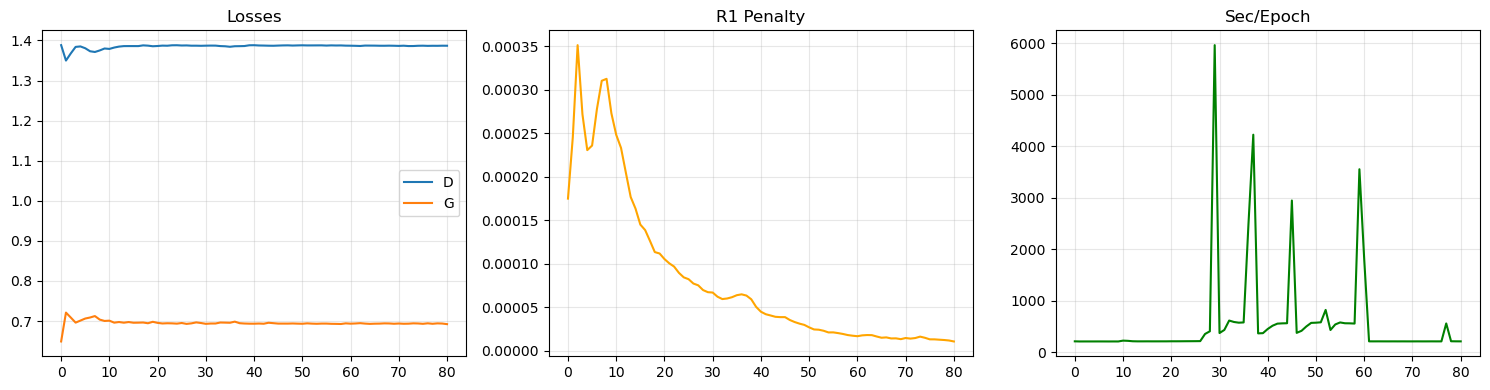

In [ ]:
if logs:
    ep = [l['epoch'] for l in logs]
    fig, (a1,a2,a3) = plt.subplots(1, 3, figsize=(15, 4))
    a1.plot(ep, [l['d'] for l in logs], label='D'); a1.plot(ep, [l['g'] for l in logs], label='G')
    a1.legend(); a1.set_title('Losses'); a1.grid(alpha=0.3)
    a2.plot(ep, [l['r1'] for l in logs], color='orange')
    a2.set_title('R1 Penalty'); a2.grid(alpha=0.3)
    a3.plot(ep, [l['t'] for l in logs], color='green')
    a3.set_title('Sec/Epoch'); a3.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/curves.png', dpi=150); plt.show()

## 7 — Visual QC

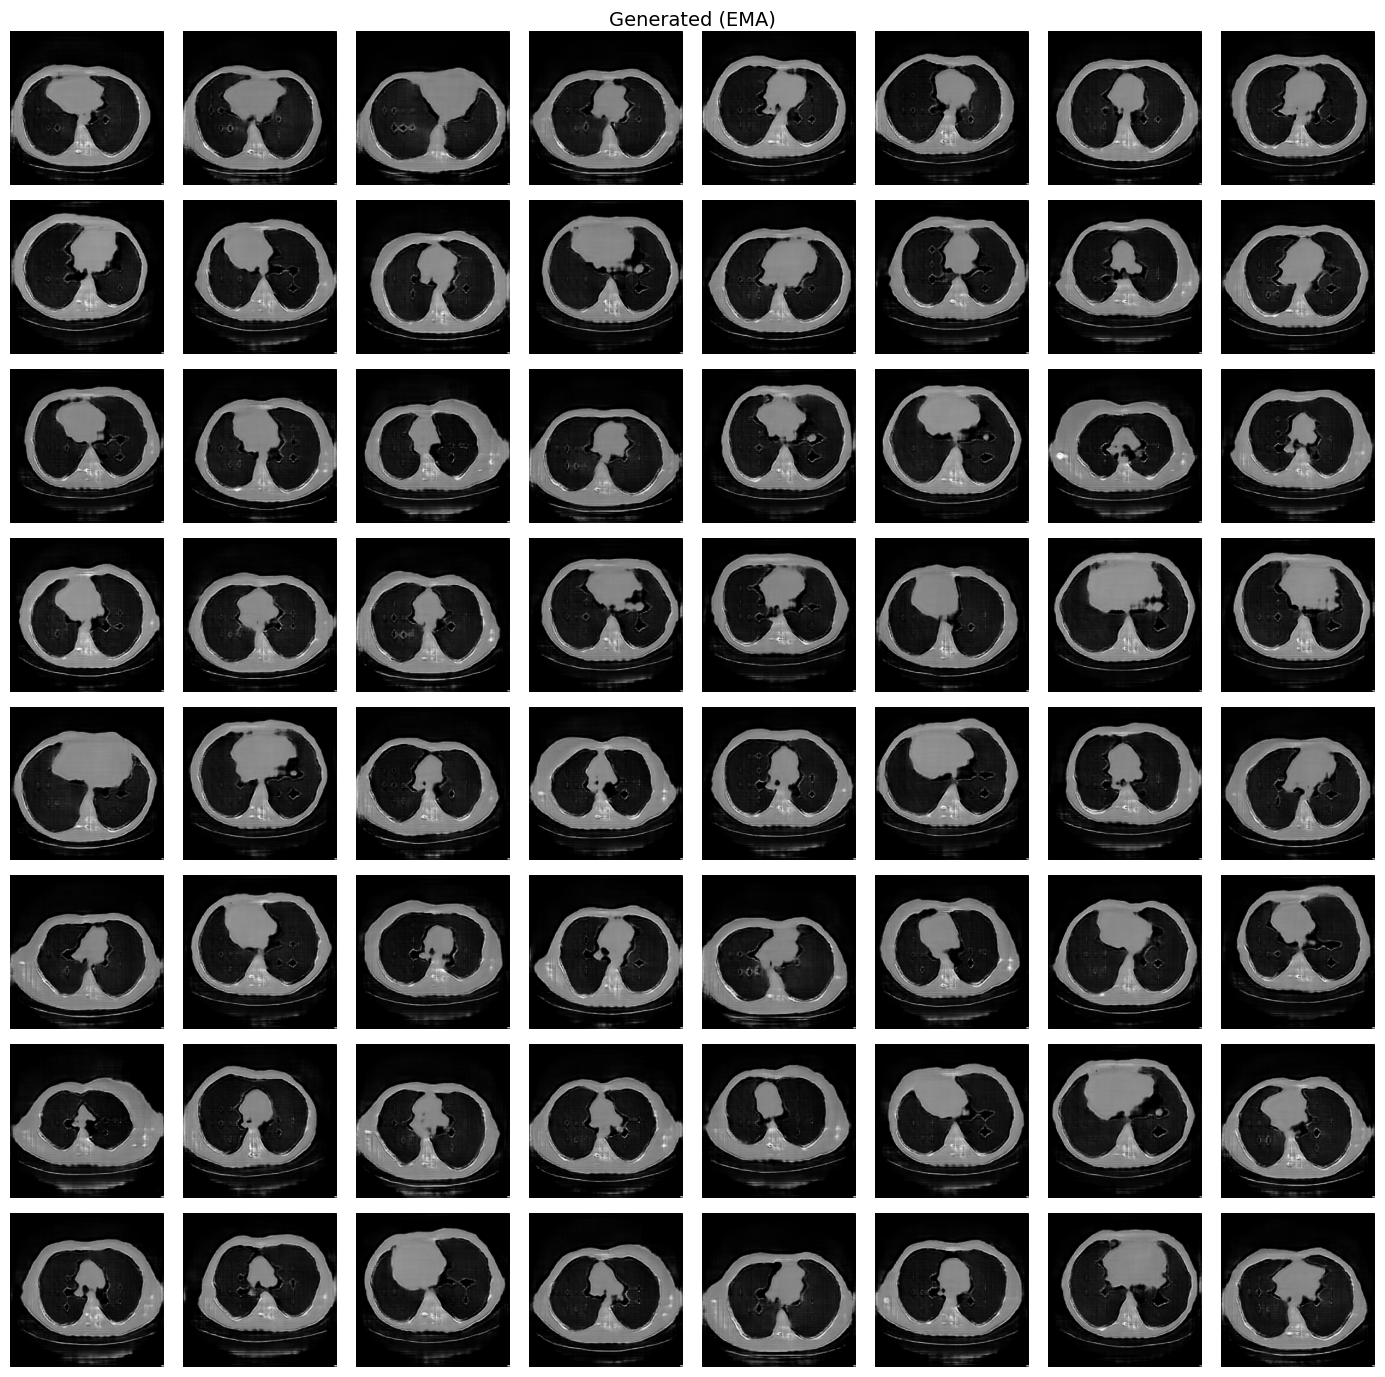

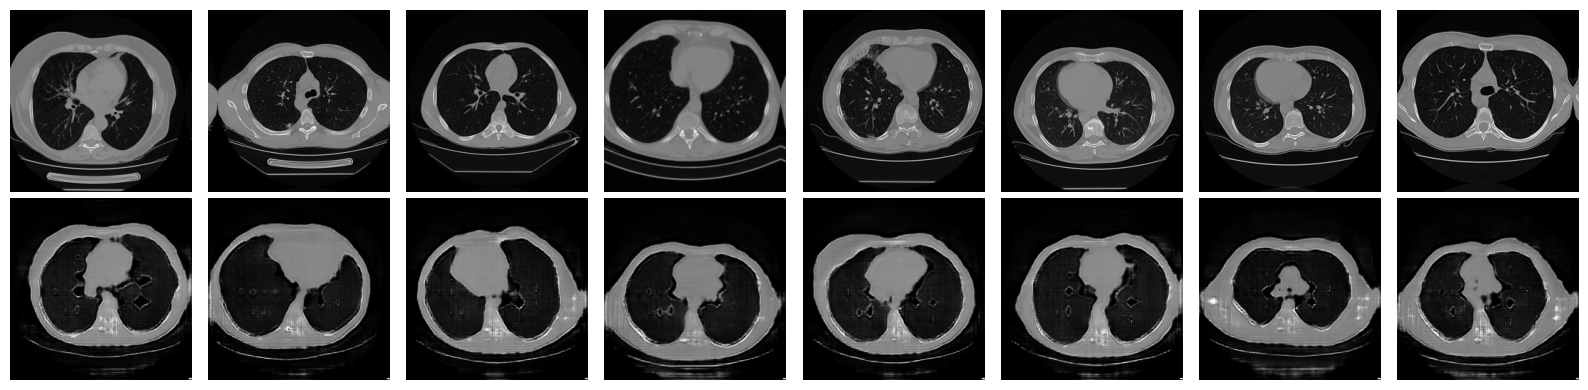

In [ ]:
G_ema.eval()
with torch.no_grad():
    gen = (G_ema(torch.randn(64, C['z_dim'], device=device)) + 1) / 2

fig, ax = plt.subplots(8, 8, figsize=(14, 14))
for i in range(64):
    ax[i//8, i%8].imshow(gen[i,0].cpu().numpy(), cmap='gray'); ax[i//8, i%8].axis('off')
plt.suptitle('Generated (EMA)', fontsize=14); plt.tight_layout(); plt.show()

real = (next(iter(dl))[:8] + 1) / 2
with torch.no_grad():
    fake = (G_ema(torch.randn(8, C['z_dim'], device=device)) + 1) / 2
fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    ax[0,i].imshow(real[i,0].numpy(), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(fake[i,0].cpu().numpy(), cmap='gray'); ax[1,i].axis('off')
ax[0,0].set_ylabel('Real', rotation=0, labelpad=35)
ax[1,0].set_ylabel('Fake', rotation=0, labelpad=35)
plt.tight_layout(); plt.show()

## 8 — Privacy Check

NN distances — Min: 33.3  Mean: 42.5  Max: 55.8


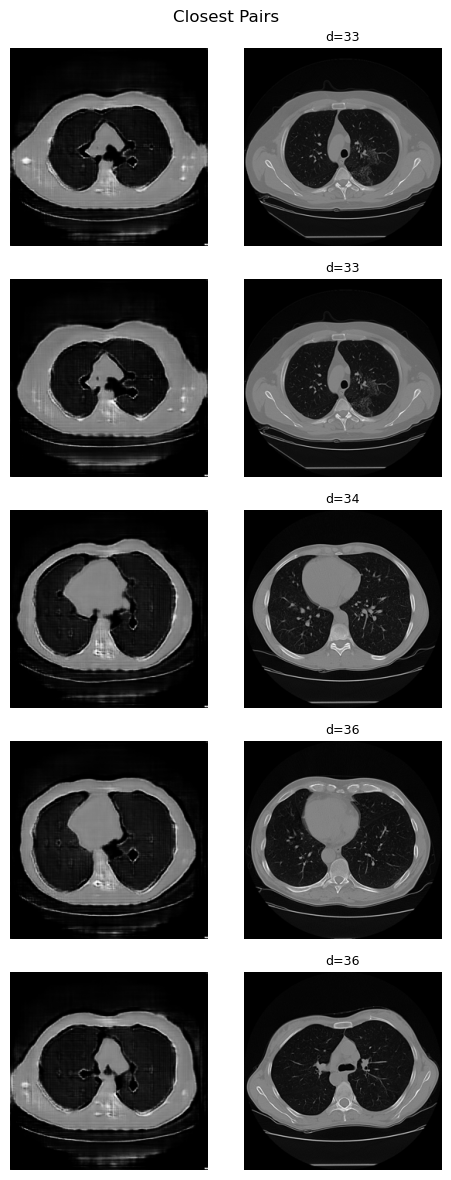

In [ ]:
nr = min(500, len(ds)); nf = 200
real_f = (ds.data[:nr].float() / 255.0).view(nr, -1)
G_ema.eval()
with torch.no_grad():
    fake_f = ((G_ema(torch.randn(nf, C['z_dim'], device=device))+1)/2).cpu().view(nf,-1)
dists = torch.cdist(fake_f, real_f, p=2)
nn_d, nn_i = dists.min(1)
print(f'NN distances — Min: {nn_d.min():.1f}  Mean: {nn_d.mean():.1f}  Max: {nn_d.max():.1f}')

top5d, top5i = nn_d.topk(5, largest=False)
fig, ax = plt.subplots(5, 2, figsize=(5, 12))
for i in range(5):
    fi, ri = top5i[i].item(), nn_i[top5i[i]].item()
    ax[i,0].imshow(fake_f[fi].view(256,256).numpy(), cmap='gray'); ax[i,0].axis('off')
    ax[i,1].imshow(real_f[ri].view(256,256).numpy(), cmap='gray'); ax[i,1].axis('off')
    ax[i,1].set_title(f'd={top5d[i]:.0f}', fontsize=9)
plt.suptitle('Closest Pairs'); plt.tight_layout(); plt.show()
del real_f, fake_f, dists
if device.type == 'mps': torch.mps.empty_cache()

## 9 — Generate 5000 & ZIP

In [ ]:
NUM = 5000; PHASE = 'dev'
torch.manual_seed(42); G_ema.eval()
syn = Path(OUTPUT_DIR) / 'submission' / 'synthetic_dir'
if syn.exists(): shutil.rmtree(syn)
syn.mkdir(parents=True)
done = 0; t0 = time.time()
with torch.no_grad():
    while done < NUM:
        bs = min(100, NUM-done)
        imgs = ((G_ema(torch.randn(bs, C['z_dim'], device=device))+1)/2).clamp(0,1)
        imgs = (imgs*255).byte().cpu()
        for i in range(bs):
            Image.fromarray(imgs[i,0].numpy(), 'L').save(syn/f'synthetic_{done+i+1:06d}.png')
        done += bs
        if done % 1000 == 0: print(f'  {done}/{NUM}')
print(f'Generated in {time.time()-t0:.0f}s')

zp = Path(OUTPUT_DIR) / f'submission_task3_{PHASE}_{datetime.now().strftime("%Y%m%d_%H%M%S")}.zip'
with zipfile.ZipFile(zp, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(syn.glob('*.png')): zf.write(f, f'synthetic_dir/{f.name}')
    if PHASE == 'test':
        ck = f'{OUTPUT_DIR}/checkpoint_best.pth' if os.path.exists(f'{OUTPUT_DIR}/checkpoint_best.pth') else f'{OUTPUT_DIR}/checkpoint.pth'
        if os.path.exists(ck): zf.write(ck, 'checkpoint.pth')
with zipfile.ZipFile(zp) as zf:
    n = len([x for x in zf.namelist() if x.endswith('.png')])
print(f'{zp.name}: {os.path.getsize(zp)/1e6:.1f} MB, {n} imgs')
print('✓ Ready!' if n == NUM else '⚠ Count mismatch!')

  1000/5000
  2000/5000
  3000/5000
  4000/5000
  5000/5000
Generated in 35s
submission_task3_dev_20260420_091219.zip: 140.9 MB, 5000 imgs
✓ Ready!


## 10 — Export Files (test phase)

In [ ]:
model_py = '''"""ImageCLEFmed GANs 2026 Task 3"""
import torch, torch.nn as nn, torch.nn.functional as F

def upblock(ic, oc):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.Conv2d(ic, oc, 3, 1, 1, bias=False), nn.GroupNorm(min(8,oc), oc), nn.LeakyReLU(0.2, True),
        nn.Conv2d(oc, oc, 3, 1, 1, bias=False), nn.GroupNorm(min(8,oc), oc), nn.LeakyReLU(0.2, True))

class Generator(nn.Module):
    def __init__(self, z=128, ch=48):
        super().__init__()
        self.z_dim, self.ch = z, ch
        self.fc = nn.Linear(z, 8*ch*16)
        self.blocks = nn.ModuleList([
            upblock(8*ch,8*ch), upblock(8*ch,4*ch), upblock(4*ch,2*ch),
            upblock(2*ch,ch), upblock(ch,ch), upblock(ch,ch)])
        self.to_img = nn.Sequential(nn.Conv2d(ch, 1, 3, 1, 1), nn.Tanh())
    def forward(self, z):
        x = self.fc(z).view(-1, 8*self.ch, 4, 4)
        for b in self.blocks: x = b(x)
        return self.to_img(x)

class Discriminator(nn.Module):
    def __init__(self, ch=24):
        super().__init__()
        c = ch
        self.net = nn.Sequential(
            nn.Conv2d(1,c,3,1,1), nn.LeakyReLU(0.2,True), nn.AvgPool2d(2),
            *[l for ic,oc in [(c,2*c),(2*c,4*c),(4*c,4*c),(4*c,4*c),(4*c,4*c)]
              for l in [nn.Conv2d(ic,oc,3,1,1),nn.LeakyReLU(0.2,True),
                        nn.Conv2d(oc,oc,3,1,1),nn.LeakyReLU(0.2,True),nn.AvgPool2d(2)]])
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(4*c*16, 1))
    def forward(self, x): return self.head(self.net(x))
'''

load_py = '''"""Generate 5000 images"""
import os, torch
from PIL import Image
from model import Generator
def main():
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    ck = torch.load("checkpoint.pth", map_location=dev, weights_only=False)
    cfg = ck.get("cfg", {})
    G = Generator(z=cfg.get("z_dim",128), ch=cfg.get("g_ch",48)).to(dev)
    G.load_state_dict(ck.get("G_ema", ck["G"])); G.eval()
    os.makedirs("synthetic_dir", exist_ok=True)
    torch.manual_seed(42); done = 0
    with torch.no_grad():
        while done < 5000:
            bs = min(100, 5000-done)
            imgs = ((G(torch.randn(bs, cfg.get("z_dim",128), device=dev))+1)/2).clamp(0,1)*255
            for i in range(bs):
                Image.fromarray(imgs[i,0].byte().cpu().numpy(),"L").save(
                    f"synthetic_dir/synthetic_{done+i+1:06d}.png")
            done += bs
            if done % 1000 == 0: print(f"{done}/5000")
    print("Done")
if __name__ == "__main__": main()
'''

out = Path(OUTPUT_DIR) / 'submission_files'; out.mkdir(exist_ok=True)
for name, txt in [('model.py',model_py),('load_model.py',load_py),('requirements.txt','torch>=2.0.0\nPillow>=9.5.0\n')]:
    (out/name).write_text(txt); print(f'Wrote {out/name}')

Wrote /Users/cherubim/Desktop/GAN3/output_v4/submission_files/model.py
Wrote /Users/cherubim/Desktop/GAN3/output_v4/submission_files/load_model.py
Wrote /Users/cherubim/Desktop/GAN3/output_v4/submission_files/requirements.txt


---
### Early stopping logic
- **MIN_EPOCHS = 80**: never stops before epoch 80 (needs time to learn structure)
- **PATIENCE = 30**: stops if smoothed G loss doesn't improve for 30 epochs
- **WINDOW = 20**: smooths G loss over 20-epoch rolling average
- Saves `checkpoint_best.pth` whenever a new best is found
- Downstream cells (QC, privacy, submission) automatically use the best model